In [1]:
# bibliotecas
import tensorflow as tf
import os
import random
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from matplotlib import pyplot as plt

print("GPUs disponíveis: ", len(tf.config.list_physical_devices('GPU')))

GPUs disponíveis:  1


In [2]:
# a seed
SEED = 123456
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data() # carrega as paradas

# cada classe representa uma categoria
categorias = {
    0: "Aviao",
    1: "Automovel",
    2: "Passaro",
    3: "Gato",
    4: "Cervo",
    5: "Cachorro",
    6: "Sapo",
    7: "Cavalo",
    8: "Navio",
    9: "Caminhao"
}

print("Formato do treino: ", x_train.shape)
print("Formato do teste: ", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Formato do treino:  (50000, 32, 32, 3)
Formato do teste:  (10000, 32, 32, 3)


/tmp/ipykernel_1549/2108203880.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(categorias[int(y_train[rndSamples[i]])])


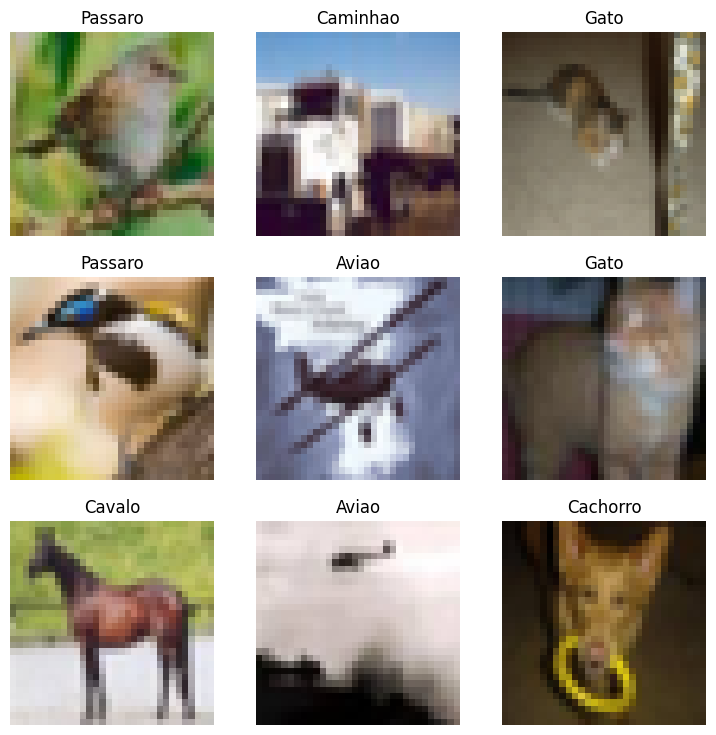

In [4]:
# visualizar as coisas
plt.figure(figsize=(9, 9))
rndSamples = np.random.choice(50000, 9)

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[rndSamples[i]])
    plt.title(categorias[int(y_train[rndSamples[i]])])
    plt.axis('off')

plt.show()

In [5]:
# o pipeline precisa ser adaptado para lidar com imagens colorida
dataset = np.concatenate([x_train, x_test], axis=0)
dataset = dataset.astype("float32") / 255 # normaliza os artefatos para o intervalo

labels = np.concatenate([y_train, y_test], axis=0).flatten() # concatena os rotulos

print(dataset.shape)

(60000, 32, 32, 3)


In [6]:
class SamplingLayer(layers.Layer):
    """Truque da Reparametrizacao: z = mu + sigma * epsilon"""

    def call(self, inputs):
        zMean, zLogVar = inputs
        batch = tf.shape(zMean)[0]
        dim = tf.shape(zMean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim)) # ruido aleatorio da distribuicao normal
        return zMean + tf.exp(0.5 * zLogVar) * epsilon # formula da reparametrizacao

In [7]:
# latentDim
LATENT_DIM = 16

def buildEncoder(latentDim, encoderInputs):
    # bloco convolucional extrai as caracteristicas visuais dos artefatos
    l1 = keras.models.Sequential([
        layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
        layers.Conv2D(64, 3, activation="relu", strides=2, padding="same"),
        layers.Conv2D(32, 3, activation="relu", strides=2, padding="same"),
        layers.Flatten(),
        layers.Dense(256, activation="relu")
    ])

    x = l1(encoderInputs)
    zMean = layers.Dense(latentDim, name="z_mean")(x) # aprende a media da distribuicao
    zLogVar = layers.Dense(latentDim, name="z_log_var")(x) # aprende a variancia da distribuicao
    z = SamplingLayer()([zMean, zLogVar]) # amostra o vetor latente

    return keras.Model(encoderInputs, [zMean, zLogVar, z], name="encoder")

encoderInputs = keras.Input(shape=(32, 32, 3))
encoder = buildEncoder(LATENT_DIM, encoderInputs)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256)       │    227,168 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      4,112 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      4,112 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer      │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (SamplingLayer)     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 235,392 (919.50 KB)

 Trainable params: 235,392 (919.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
def buildDecoder(latentInputs):
    # simetrico ao encoder com conv2dtranspose
    l1 = keras.models.Sequential([
        layers.Dense(4*4*64, activation="relu", input_shape=(latentInputs.shape[1],)),
        layers.Reshape((4, 4, 64)),
        layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same"),
        layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same"),
        layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same"),
        layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same") # 3 canais rgb na saida
    ])

    return keras.Model(latentInputs, l1(latentInputs), name="decoder")

latentInputs = keras.Input(shape=(LATENT_DIM,))
decoder = buildDecoder(latentInputs)
decoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │       184,387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,387 (720.26 KB)

 Trainable params: 184,387 (720.26 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def reconstructionLoss(data, reconstructed):
    # penaliza artefatos reconstruidos
    return tf.reduce_mean(
        tf.reduce_sum(
            keras.losses.binary_crossentropy(data, reconstructed),
            axis=(1, 2)
        )
    )

def klDivergenceLoss(zMean, zLogVar):
    # penaliza o modelo se a distribuicao
    return tf.reduce_mean(
        tf.reduce_sum(
            -0.5 * (1 + zLogVar - tf.square(zMean) - tf.exp(zLogVar)),
            axis=1
        )
    )

def calcTotalLoss(data, reconstructed, zMean, zLogVar):
    loss1 = reconstructionLoss(data, reconstructed)
    loss2 = klDivergenceLoss(zMean, zLogVar)
    klWeight = 3.0 # peso para equilibrar
    return loss1, loss2, loss1 + klWeight * loss2

In [10]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.totalLossTracker = keras.metrics.Mean(name="total_loss")
        self.ceLossTracker = keras.metrics.Mean(name="ce_loss")
        self.klLossTracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.totalLossTracker, self.ceLossTracker, self.klLossTracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            zMean, zLogVar, z = self.encoder(data)
            reconstruction = self.decoder(z)
            ceLoss, klLoss, totalLoss = calcTotalLoss(data, reconstruction, zMean, zLogVar)

        # calcula os gradientes e atualiz
        grads = tape.gradient(totalLoss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.totalLossTracker.update_state(totalLoss)
        self.ceLossTracker.update_state(ceLoss)
        self.klLossTracker.update_state(klLoss)

        return {
            "perda_total": self.totalLossTracker.result(),
            "perda_reconstrucao": self.ceLossTracker.result(),
            "perda_kl": self.klLossTracker.result()
        }

In [11]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))
history = vae.fit(dataset, epochs=32, batch_size=128) # treina o catalogador

Epoch 1/32
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - perda_kl: 3.8861 - perda_reconstrucao: 659.0529 - perda_total: 670.7114
Epoch 2/32
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - perda_kl: 5.5971 - perda_reconstrucao: 637.4876 - perda_total: 654.2791
Epoch 3/32
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - perda_kl: 5.9973 - perda_reconstrucao: 634.5377 - perda_total: 652.5294
Epoch 4/32
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - perda_kl: 6.5268 - perda_reconstrucao: 631.2601 - perda_total: 650.8405
Epoch 5/32
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - perda_kl: 6.7825 - perda_reconstrucao: 629.5164 - perda_total: 649.8639
Epoch 6/32
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - perda_kl: 6.8588 - perda_reconstrucao: 628.7966 - perda_total: 649.3732
Epoch 7/32
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - perda_kl: 6.9411 - perda_reconstrucao: 628.3421 - perda_total: 649.1652
Epoch 8/32
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - perda_kl: 6.9871 - perda_reconstrucao: 627.9565 - perda

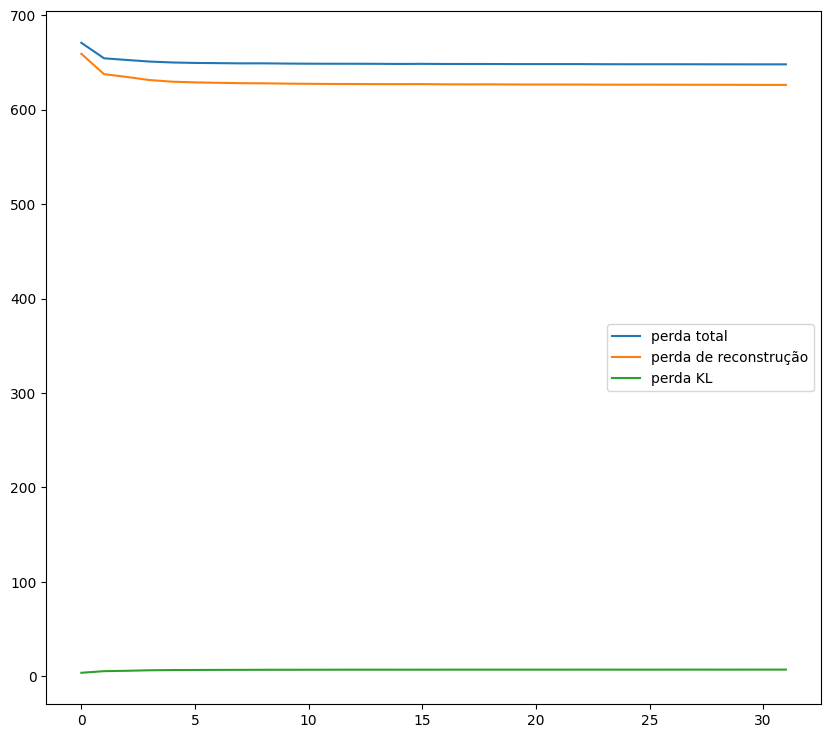

In [12]:
plt.figure(figsize=(10, 9))
plt.plot(history.history.get('perda_total'), label="perda total")
plt.plot(history.history.get('perda_reconstrucao'), label="perda de reconstrução")
plt.plot(history.history.get('perda_kl'), label="perda KL")
plt.legend()
plt.show()

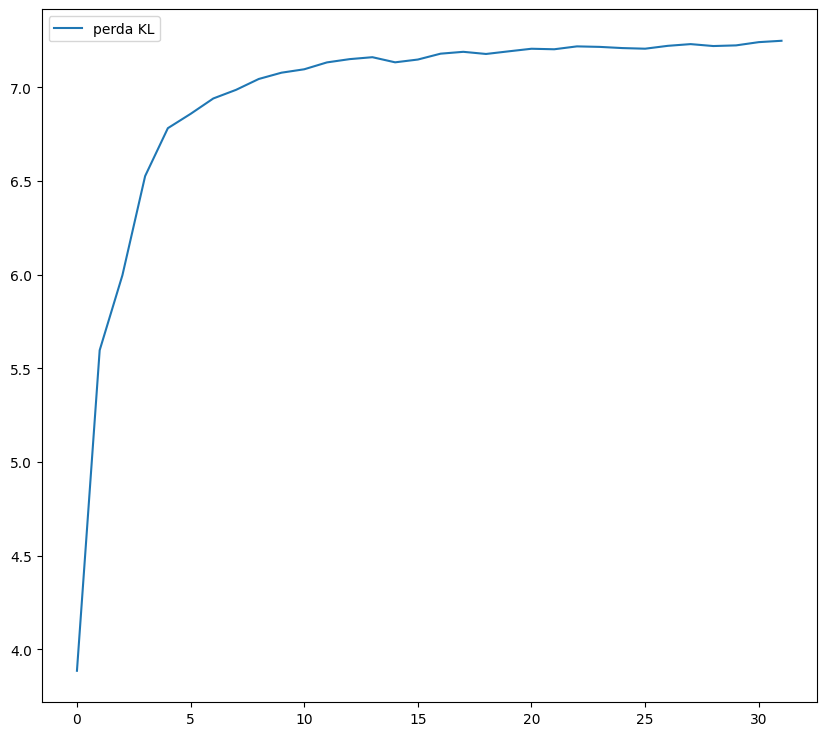

In [13]:
# zoom na perda kl
plt.figure(figsize=(10, 9))
plt.plot(history.history.get('perda_kl'), label="perda KL")
plt.legend()
plt.show()

In [14]:
idx = 42 # indice da image
batch = np.expand_dims(x_train[idx], axis=0).astype("float32") / 255
print("Formato do lote: ", batch.shape)
print("Categoria do artefato: ", categorias[int(y_train[idx])])

_, _, z = vae.encoder.predict(batch) # codifica o artefato no espaco
synth = vae.decoder.predict([z]) # reconstroi o artefato
z

Formato do lote:  (1, 32, 32, 3)
Categoria do artefato:  Passaro


/tmp/ipykernel_1549/745264463.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Categoria do artefato: ", categorias[int(y_train[idx])])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_11
Received: inputs=('Tensor(shape=(1, 16))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step


array([[-2.3869145 ,  0.44090593,  0.35807598, -0.981596  ,  0.20462918,
        -0.57751346,  0.23674934,  1.0467418 , -0.6180065 ,  0.14043844,
         0.8483325 , -1.2301178 ,  0.76828617, -0.7340077 ,  0.5402655 ,
         1.2010727 ]], dtype=float32)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


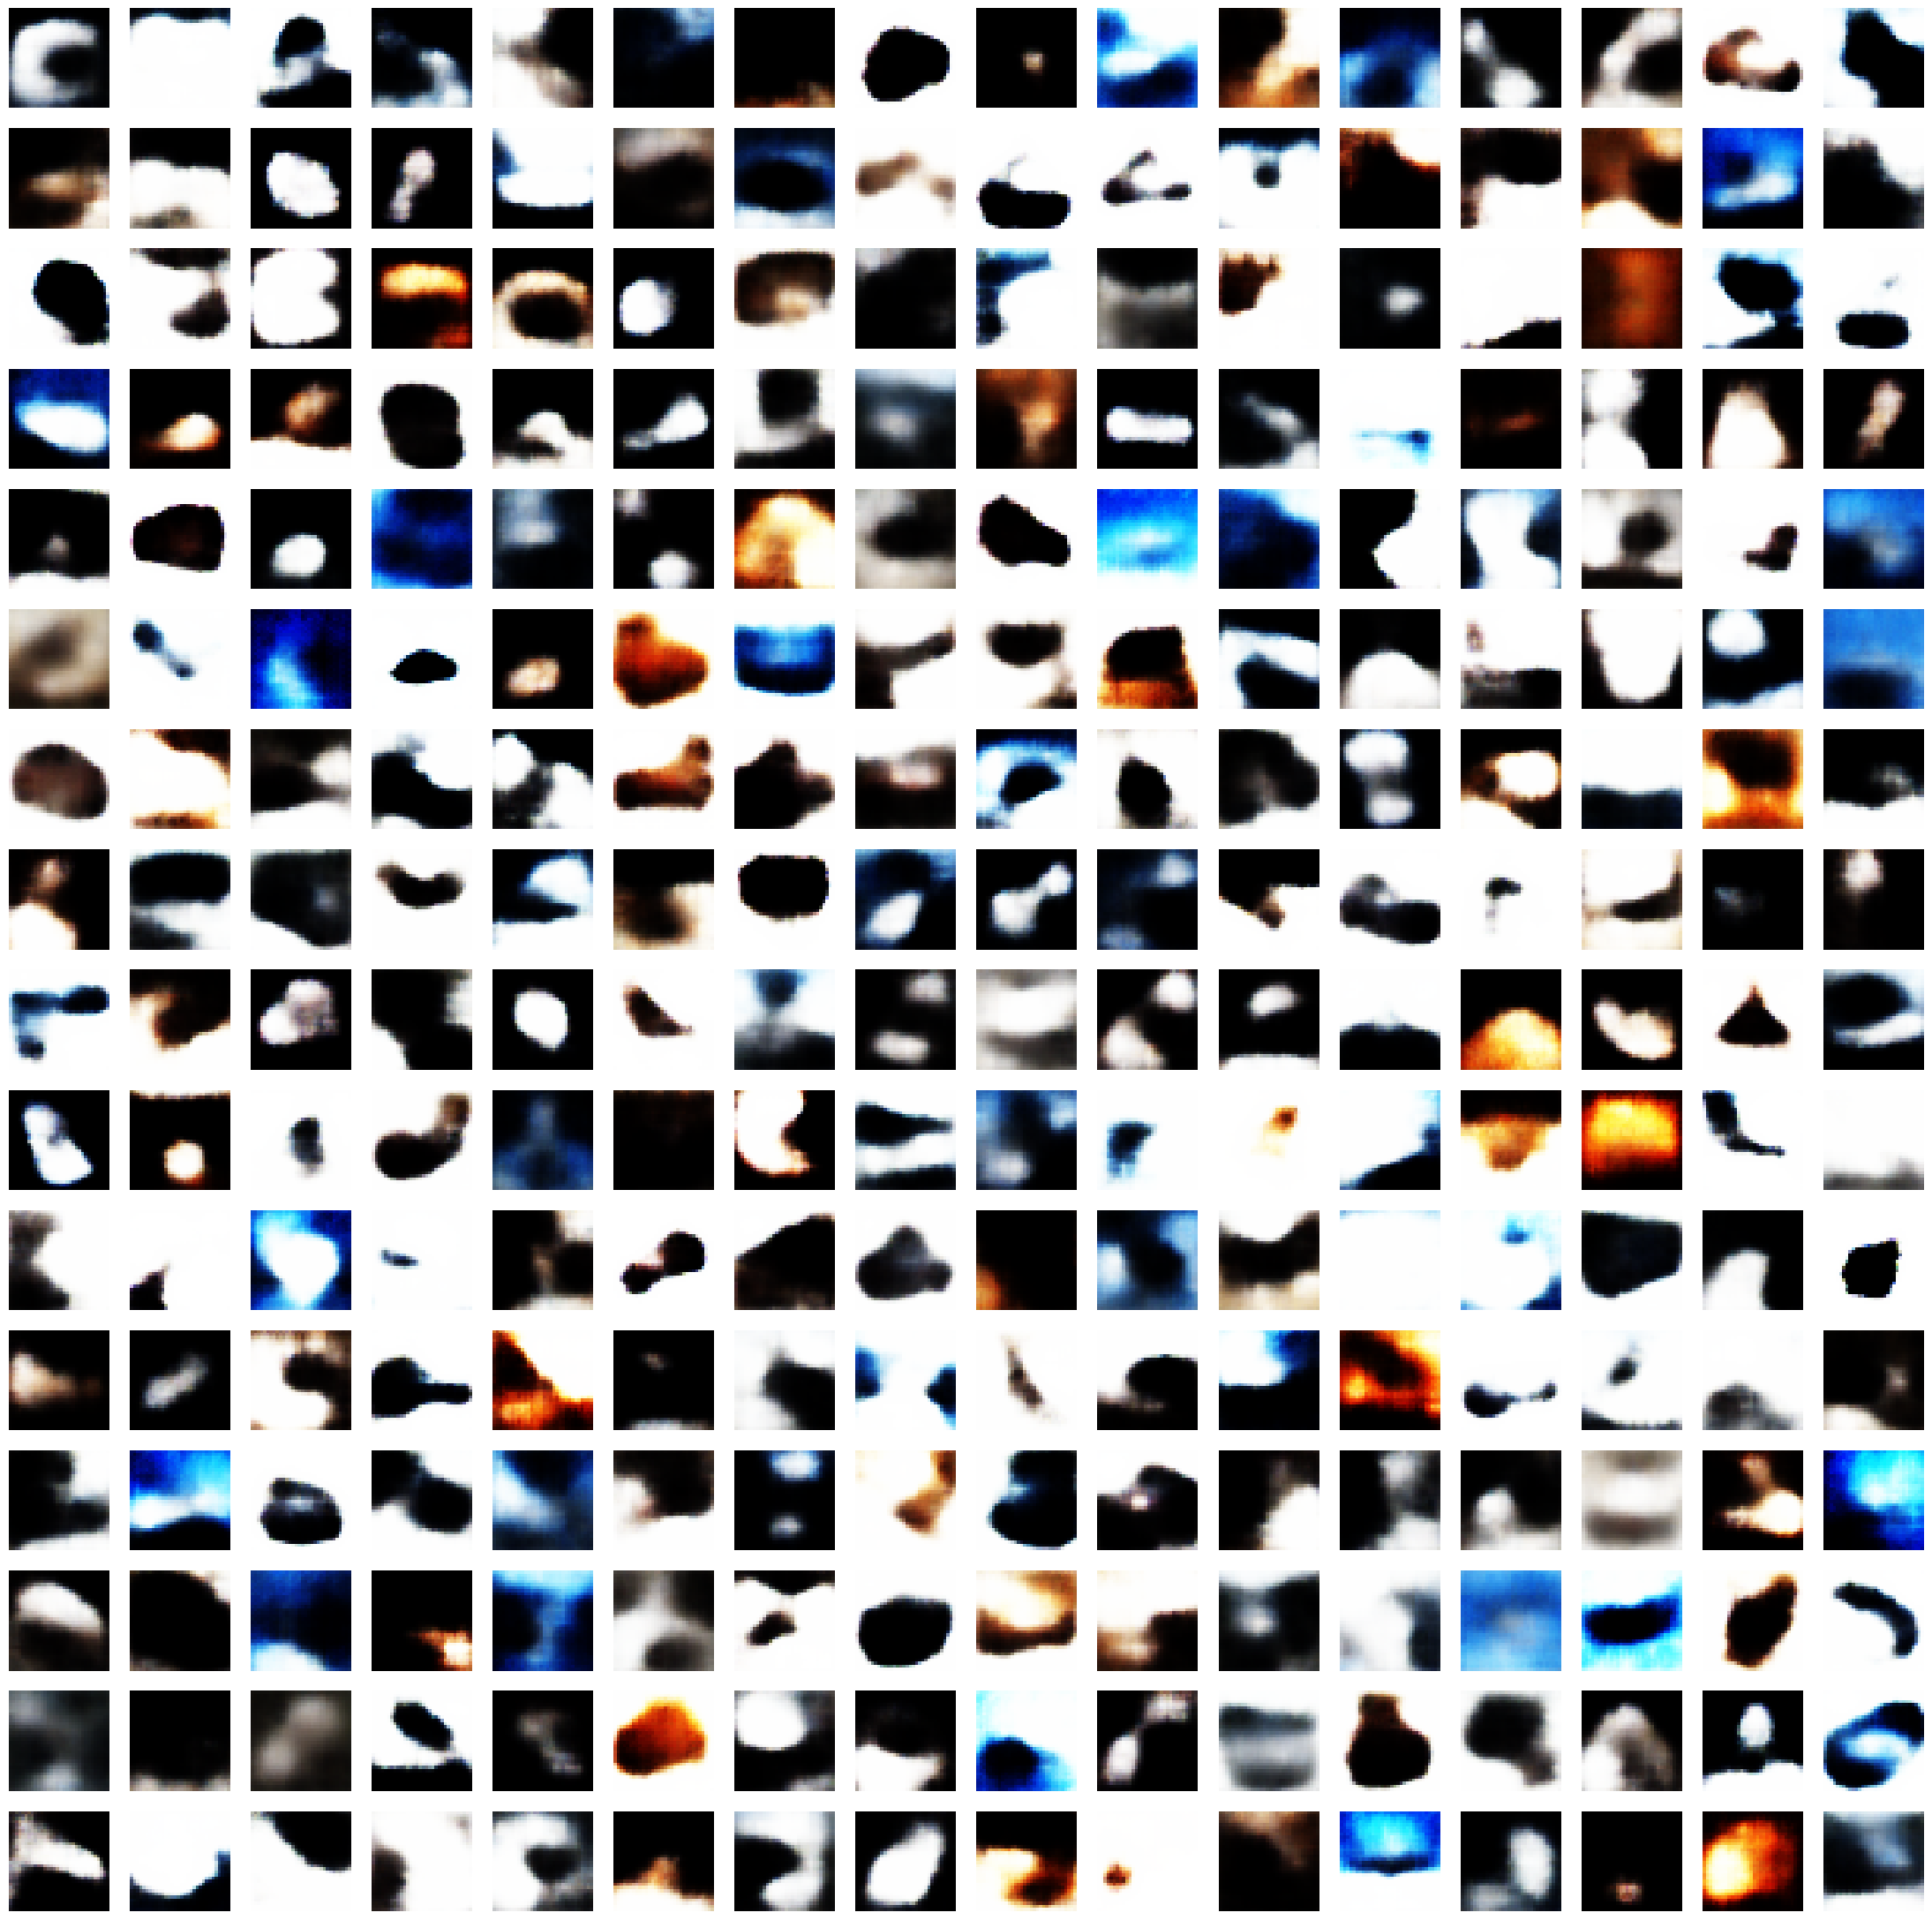

In [15]:
# gera 256 imagens sinteticos a partir de pontos
z = np.random.normal(loc=0, scale=4, size=(256, LATENT_DIM))
synth = vae.decoder.predict(z)
plt.figure(figsize=(28, 28))

for i in range(256):
    plt.subplot(16, 16, i+1)
    plt.imshow(synth[i])
    plt.axis('off')

plt.show()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


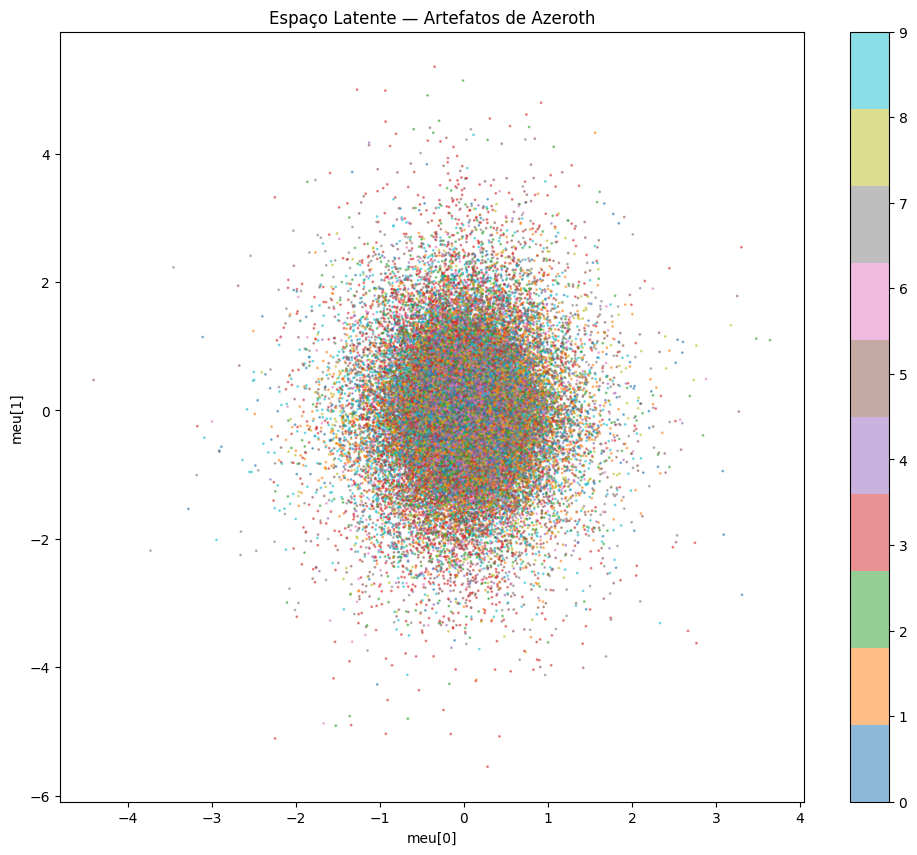

In [16]:
# mostra como o vae agrupou os artefatos de azeroth por categoria
meu, _, _ = vae.encoder.predict(dataset)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(meu[:, 0], meu[:, 1], c=labels, cmap="tab10", alpha=0.5, s=1)
plt.colorbar(scatter, ticks=range(10))
plt.xlabel("meu[0]")
plt.ylabel("meu[1]")
plt.title("Espaço Latente — Artefatos de Azeroth")
plt.show()